<a href="https://colab.research.google.com/github/jessisam2007/24BAD049_24ADI006-DeepLearning/blob/main/24BAD049_DL_EXP2_COLAB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experiment 2: Comparative Study of Activation Functions and Optimization Algorithms in Deep Learning

**Aim:** To analyze the impact of different activation functions and optimization algorithms on the performance of Artificial Neural Networks (ANNs), and to learn best practices for managing deep learning experiments using cloud-based tools and version control.




In [ ]:
import tensorflow as tf
import matplotlib
print("TensorFlow version:", tf.__version__)
print("Matplotlib version:", matplotlib.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


---
## Task A: Visualization of Activation Functions

24BAD049 - JESSICA SAM B


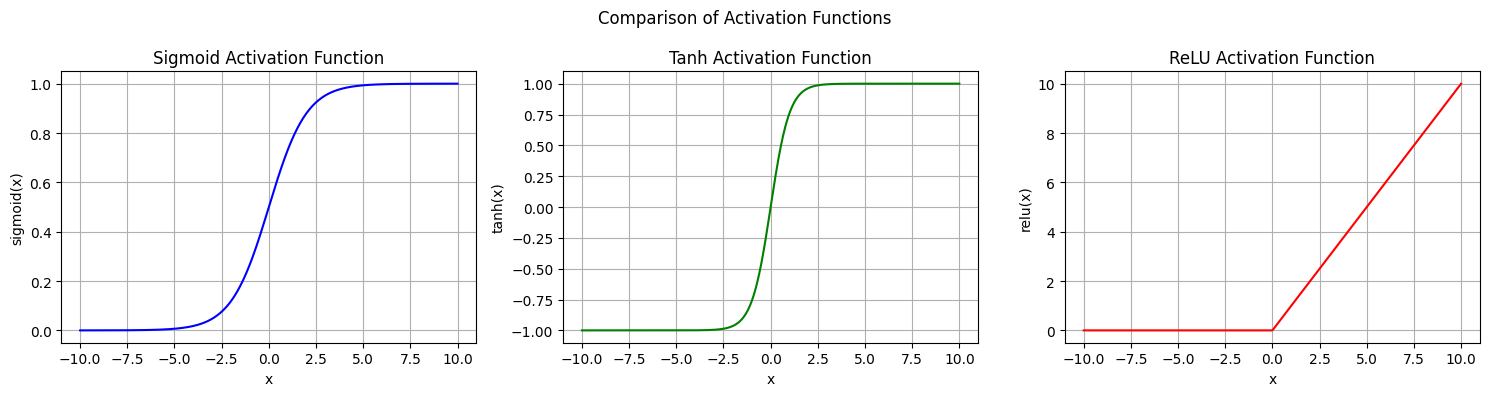

Function  | Output Range | Saturation                | Gradient Behaviour
--------------------------------------------------------------------------------
Sigmoid   | (0, 1)       | Saturates both ends       | Smooth, vanishes for large |x|
Tanh      | (-1, 1)      | Saturates both ends       | Zero-centred, vanishes for large |x|
ReLU      | [0, inf)     | Saturates only for x < 0  | Constant (1) for x>0, 0 for x<0


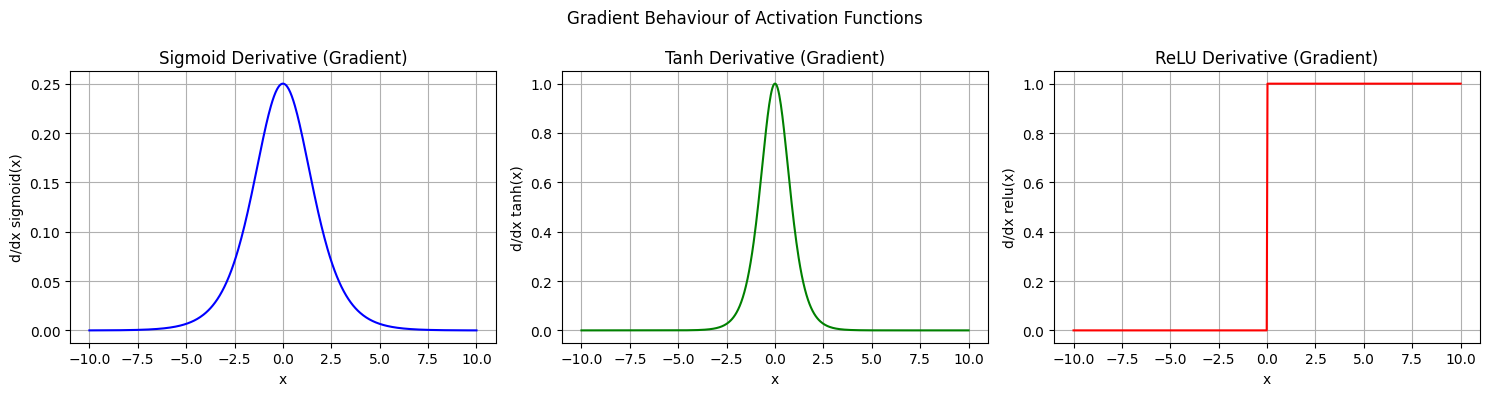

In [ ]:
print("24BAD049 - JESSICA SAM B")
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)

def tanh(x):
    return np.tanh(x)

def tanh_derivative(x):
    return 1 - np.tanh(x) ** 2

def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return np.where(x > 0, 1, 0)

x = np.linspace(-10, 10, 500)

y_sigmoid = sigmoid(x)
y_tanh = tanh(x)
y_relu = relu(x)

d_sigmoid = sigmoid_derivative(x)
d_tanh = tanh_derivative(x)
d_relu = relu_derivative(x)

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.plot(x, y_sigmoid, color='blue')
plt.title("Sigmoid Activation Function")
plt.xlabel("x"); plt.ylabel("sigmoid(x)"); plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(x, y_tanh, color='green')
plt.title("Tanh Activation Function")
plt.xlabel("x"); plt.ylabel("tanh(x)"); plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(x, y_relu, color='red')
plt.title("ReLU Activation Function")
plt.xlabel("x"); plt.ylabel("relu(x)"); plt.grid(True)

plt.suptitle("Comparison of Activation Functions")
plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.plot(x, d_sigmoid, color='blue')
plt.title("Sigmoid Derivative (Gradient)")
plt.xlabel("x"); plt.ylabel("d/dx sigmoid(x)"); plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(x, d_tanh, color='green')
plt.title("Tanh Derivative (Gradient)")
plt.xlabel("x"); plt.ylabel("d/dx tanh(x)"); plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(x, d_relu, color='red')
plt.title("ReLU Derivative (Gradient)")
plt.xlabel("x"); plt.ylabel("d/dx relu(x)"); plt.grid(True)

plt.suptitle("Gradient Behaviour of Activation Functions")
plt.tight_layout()

print("Function  | Output Range | Saturation                | Gradient Behaviour")
print("-" * 80)
print("Sigmoid   | (0, 1)       | Saturates both ends       | Smooth, vanishes for large |x|")
print("Tanh      | (-1, 1)      | Saturates both ends       | Zero-centred, vanishes for large |x|")
print("ReLU      | [0, inf)     | Saturates only for x < 0  | Constant (1) for x>0, 0 for x<0")


---
## Task B: Performance Comparison of Activation Functions

24BAD049 - JESSICA SAM B
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Training model with 'sigmoid' activation...


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


sigmoid -> Final Train Acc: 0.9837, Final Val Acc: 0.9750

Training model with 'tanh' activation...
tanh -> Final Train Acc: 0.9943, Final Val Acc: 0.9763

Training model with 'relu' activation...
relu -> Final Train Acc: 0.9949, Final Val Acc: 0.9778


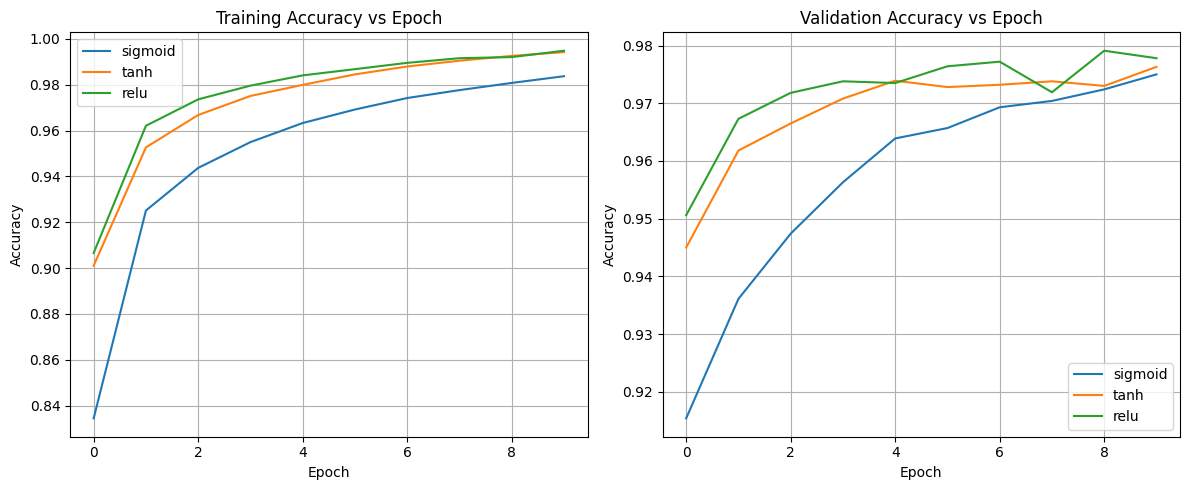

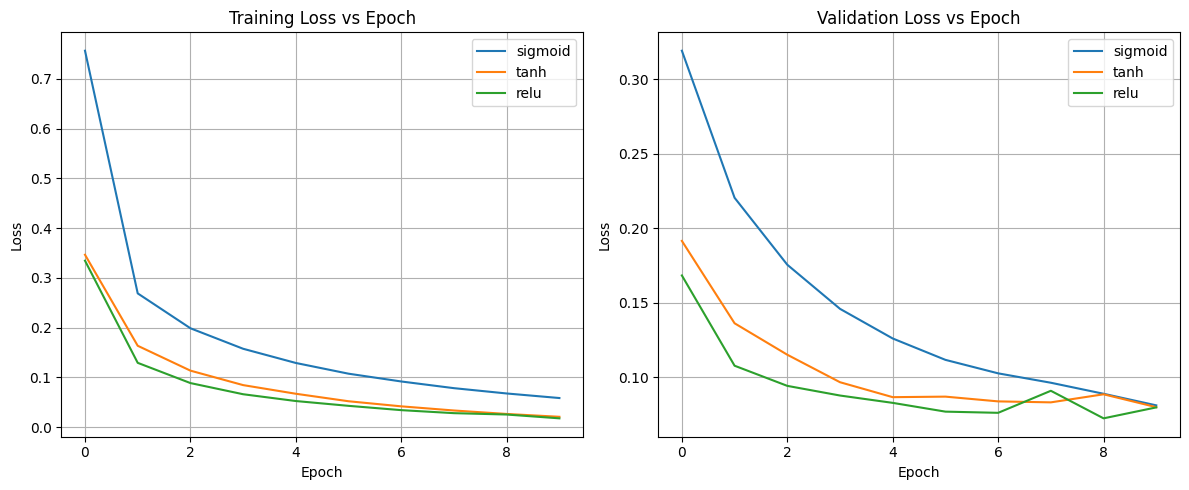

ActivationTrain Acc   Val Acc     Train Loss  Val Loss    
sigmoid   0.9837      0.9750      0.0584      0.0812      
tanh      0.9943      0.9763      0.0207      0.0800      
relu      0.9949      0.9778      0.0176      0.0798      


In [ ]:
print("24BAD049 - JESSICA SAM B")

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
x_train = x_train.reshape(-1, 784).astype("float32") / 255.0
x_test = x_test.reshape(-1, 784).astype("float32") / 255.0

def build_model(activation):
    model = keras.Sequential([
        layers.Dense(128, activation=activation, input_shape=(784,)),
        layers.Dense(64, activation=activation),
        layers.Dense(10, activation="softmax")
    ])
    model.compile(optimizer="adam",
                   loss="sparse_categorical_crossentropy",
                   metrics=["accuracy"])
    return model

activations = ["sigmoid", "tanh", "relu"]
EPOCHS = 10
history_dict = {}

for act in activations:
    print(f"\nTraining model with '{act}' activation...")
    model = build_model(act)
    history = model.fit(x_train, y_train,
                         validation_data=(x_test, y_test),
                         epochs=EPOCHS, batch_size=128, verbose=0)
    history_dict[act] = history.history
    print(f"{act} -> Final Train Acc: {history.history['accuracy'][-1]:.4f}, "
          f"Final Val Acc: {history.history['val_accuracy'][-1]:.4f}")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
for act in activations:
    plt.plot(history_dict[act]['accuracy'], label=act)
plt.title("Training Accuracy vs Epoch")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend(); plt.grid(True)

plt.subplot(1, 2, 2)
for act in activations:
    plt.plot(history_dict[act]['val_accuracy'], label=act)
plt.title("Validation Accuracy vs Epoch")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend(); plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
for act in activations:
    plt.plot(history_dict[act]['loss'], label=act)
plt.title("Training Loss vs Epoch")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.grid(True)

plt.subplot(1, 2, 2)
for act in activations:
    plt.plot(history_dict[act]['val_loss'], label=act)
plt.title("Validation Loss vs Epoch")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.grid(True)
plt.tight_layout()
plt.show()

print(f"{'Activation':<10}{'Train Acc':<12}{'Val Acc':<12}{'Train Loss':<12}{'Val Loss':<12}")
for act in activations:
    h = history_dict[act]
    print(f"{act:<10}{h['accuracy'][-1]:<12.4f}{h['val_accuracy'][-1]:<12.4f}"
          f"{h['loss'][-1]:<12.4f}{h['val_loss'][-1]:<12.4f}")


---
## Task C: Comparison of Optimization Algorithms



24BAD049 - JESSICA SAM B

Training model with 'SGD' optimizer...
SGD -> Final Train Acc: 0.9334, Final Val Acc: 0.9358

Training model with 'Momentum' optimizer...
Momentum -> Final Train Acc: 0.9825, Final Val Acc: 0.9743

Training model with 'RMSProp' optimizer...
RMSProp -> Final Train Acc: 0.9928, Final Val Acc: 0.9780

Training model with 'Adam' optimizer...
Adam -> Final Train Acc: 0.9938, Final Val Acc: 0.9779


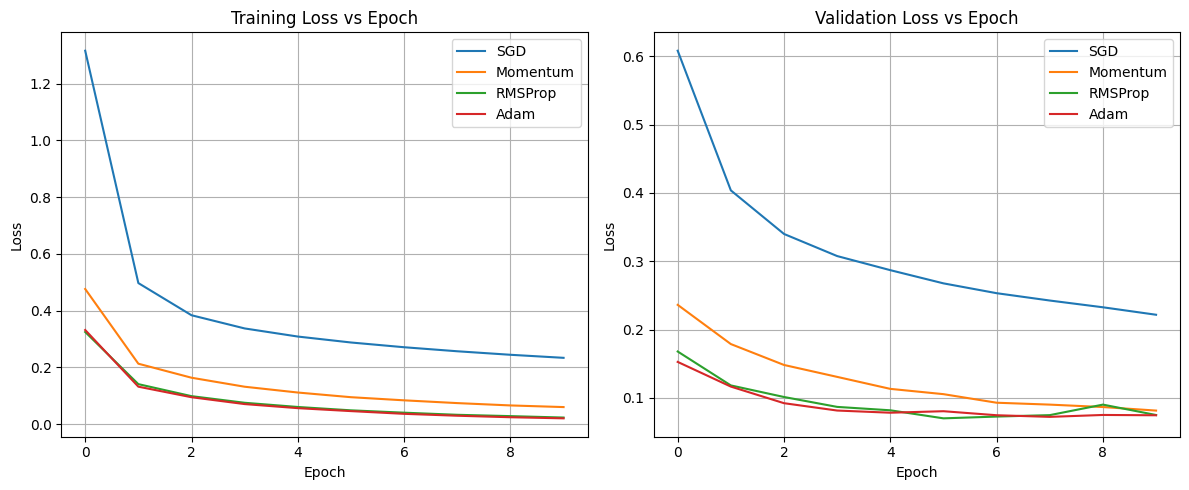

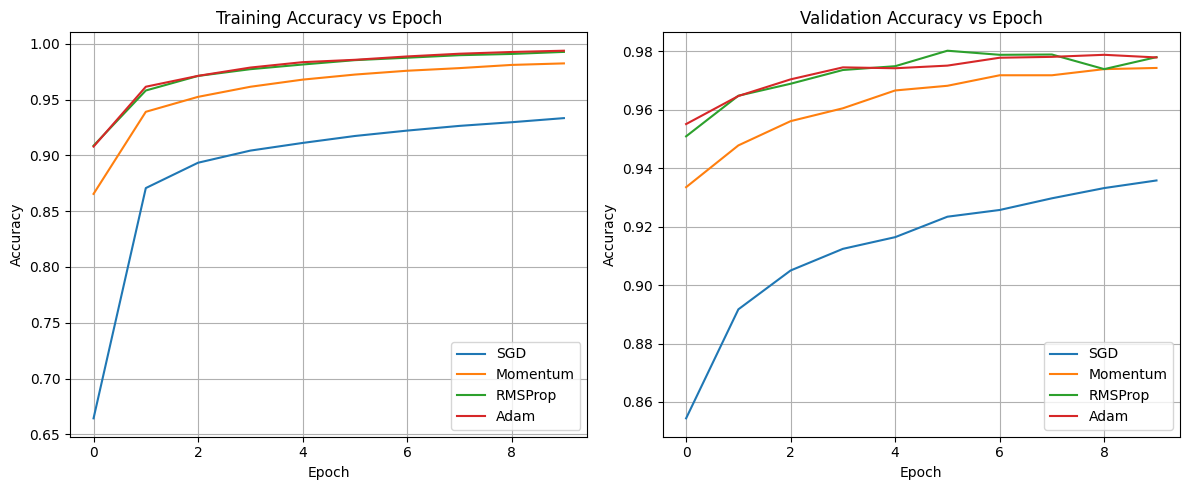

Optimizer   Train Acc   Val Acc     Train Loss  Val Loss    
SGD         0.9334      0.9358      0.2337      0.2217      
Momentum    0.9825      0.9743      0.0601      0.0814      
RMSProp     0.9928      0.9780      0.0232      0.0749      
Adam        0.9938      0.9779      0.0204      0.0745      


In [ ]:
print("24BAD049 - JESSICA SAM B")

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, optimizers
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
x_train = x_train.reshape(-1, 784).astype("float32") / 255.0
x_test = x_test.reshape(-1, 784).astype("float32") / 255.0

def build_model():
    return keras.Sequential([
        layers.Dense(128, activation="relu", input_shape=(784,)),
        layers.Dense(64, activation="relu"),
        layers.Dense(10, activation="softmax")
    ])

optimizer_dict = {
    "SGD":      optimizers.SGD(learning_rate=0.01),
    "Momentum": optimizers.SGD(learning_rate=0.01, momentum=0.9),
    "RMSProp":  optimizers.RMSprop(learning_rate=0.001),
    "Adam":     optimizers.Adam(learning_rate=0.001)
}

EPOCHS = 10
history_dict = {}

for name, opt in optimizer_dict.items():
    print(f"\nTraining model with '{name}' optimizer...")
    model = build_model()
    model.compile(optimizer=opt,
                   loss="sparse_categorical_crossentropy",
                   metrics=["accuracy"])
    history = model.fit(x_train, y_train,
                         validation_data=(x_test, y_test),
                         epochs=EPOCHS, batch_size=128, verbose=0)
    history_dict[name] = history.history
    print(f"{name} -> Final Train Acc: {history.history['accuracy'][-1]:.4f}, "
          f"Final Val Acc: {history.history['val_accuracy'][-1]:.4f}")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
for name in optimizer_dict:
    plt.plot(history_dict[name]['loss'], label=name)
plt.title("Training Loss vs Epoch")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.grid(True)

plt.subplot(1, 2, 2)
for name in optimizer_dict:
    plt.plot(history_dict[name]['val_loss'], label=name)
plt.title("Validation Loss vs Epoch")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
for name in optimizer_dict:
    plt.plot(history_dict[name]['accuracy'], label=name)
plt.title("Training Accuracy vs Epoch")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend(); plt.grid(True)

plt.subplot(1, 2, 2)
for name in optimizer_dict:
    plt.plot(history_dict[name]['val_accuracy'], label=name)
plt.title("Validation Accuracy vs Epoch")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend(); plt.grid(True)
plt.tight_layout()
plt.show()

print(f"{'Optimizer':<12}{'Train Acc':<12}{'Val Acc':<12}{'Train Loss':<12}{'Val Loss':<12}")
for name in optimizer_dict:
    h = history_dict[name]
    print(f"{name:<12}{h['accuracy'][-1]:<12.4f}{h['val_accuracy'][-1]:<12.4f}"
          f"{h['loss'][-1]:<12.4f}{h['val_loss'][-1]:<12.4f}")
